In [1]:
import matplotlib.pyplot as plt
import numpy as np
import gplugins.tidy3d as gt
import gdsfactory as gf
import sax 
import jax.numpy as jnp
from upvfab.sin300.cband import PDK, cells

## PART I. Design and Simulation of Individual Components


### 1. Simulating Propagation Modes in SOI Waveguides

#### Step 1: Define the SOI waveguide structure

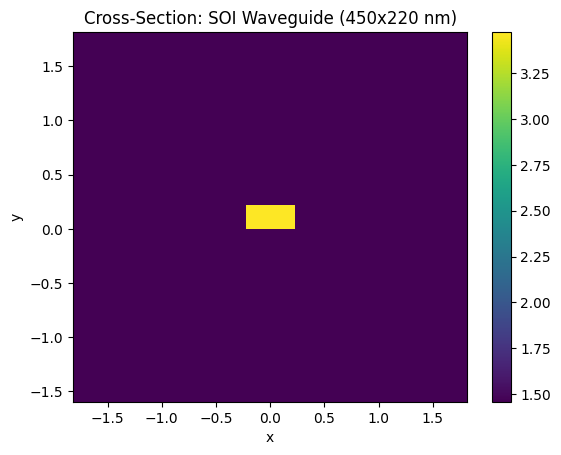

In [2]:
# Parámetros de la guía 
W = 0.45      # Ancho del núcleo: 450 nm (0.45 um)
H = 0.22      # Grosor del núcleo: 220 nm (0.22 um)
wvl = 1.55    # Longitud de onda: 1550 nm (1.55 um)

# Instanciamos la guía de onda en el simulador
waveguide = gt.modes.Waveguide(
    core_width=W,
    core_thickness=H,
    core_material="si",
    clad_material="sio2",
    wavelength=wvl,
    num_modes=4,              
    grid_resolution=20,       
    cache_path='.cache/'     
)

waveguide.plot_index()
plt.title("Cross-Section: SOI Waveguide (450x220 nm)")
plt.show()

#### Step 2: Simulate fundamental TE and TM modes

/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

19:55:50 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

              WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-25 19:55:50.632 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6899bf2cf261b966.npz.


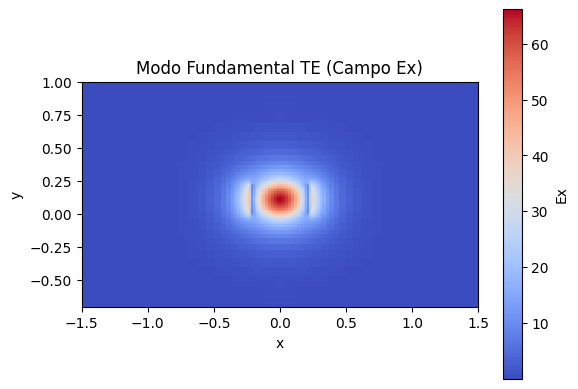

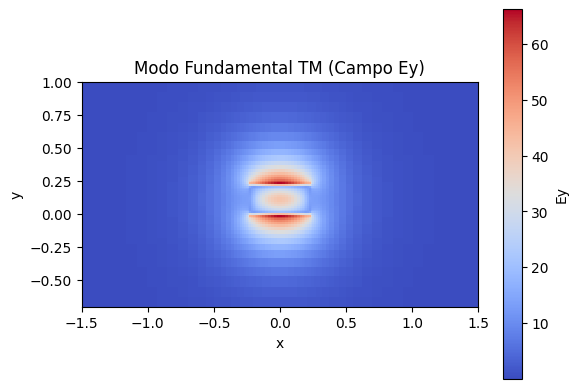

In [3]:
# 1. Modo Fundamental TE 

waveguide.plot_field(
    mode_index=0,       
    field_name='Ex',    
    value='real',       
    cmap='coolwarm',    
    xlim=(-1.5, 1.5),   
    ylim=(-0.7, 1)      
) 
plt.title('Modo Fundamental TE (Campo Ex)')
plt.show()


# 2. Modo Fundamental TM 

waveguide.plot_field(
    mode_index=1,       
    field_name='Ey',    
    value='real', 
    cmap='coolwarm', 
    xlim=(-1.5, 1.5), 
    ylim=(-0.7, 1)
) 
plt.title('Modo Fundamental TM (Campo Ey)')
plt.show()

#### Step 3: Extract effective index (n_eff) and group index (n_g)

In [4]:
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

# 1. Columnas: Longitud de onda (0) y n_eff del Modo TE (3)
wvl = SOI[:, 0]
neff_te = SOI[:, 3]

# 2. Buscar índice exacto para la longitud de onda central (1.55 um)
indice_central = np.where(np.isclose(wvl, 1.55))[0][0]

wvl_central = wvl[indice_central]
n_eff_central = neff_te[indice_central]

# 3. Calculamos la derivada (dn_eff / d_lambda) usando los puntos anterior y posterior
dn_eff = (neff_te[indice_central + 1] - neff_te[indice_central - 1]) / 2
delta_wvl = (wvl[indice_central + 1] - wvl[indice_central - 1]) / 2

dn_eff_dlambda = dn_eff / delta_wvl

# 4. Índice de Grupo (n_g)
n_g_te = n_eff_central - (wvl_central * dn_eff_dlambda)

print("--- RESULTADOS MODO FUNDAMENTAL TE ---")
print(f"n_eff TE a 1.55um: {n_eff_central:.4f}")
print(f"n_g TE calculado:  {n_g_te:.4f}")

--- RESULTADOS MODO FUNDAMENTAL TE ---
n_eff TE a 1.55um: 2.3558
n_g TE calculado:  4.2933


### 2. Designing Directional Couplers

#### Step 1: Simulate directional couplers in GDSFactory

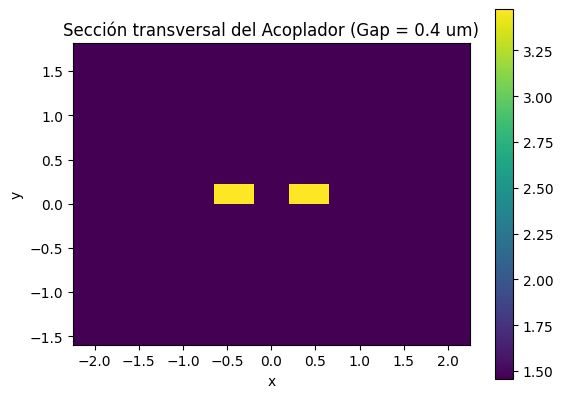

/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

2026-05-25 19:55:51.148 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e0ddedf4d2ad1493.npz.


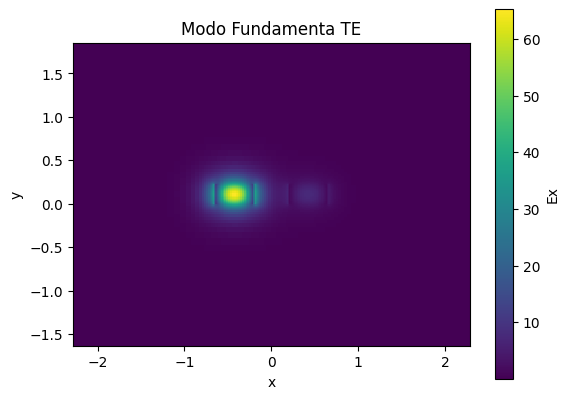

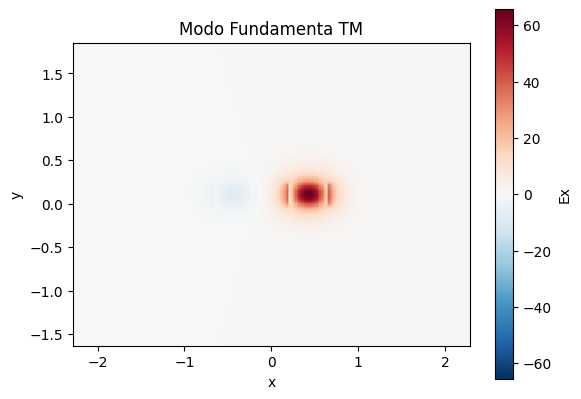

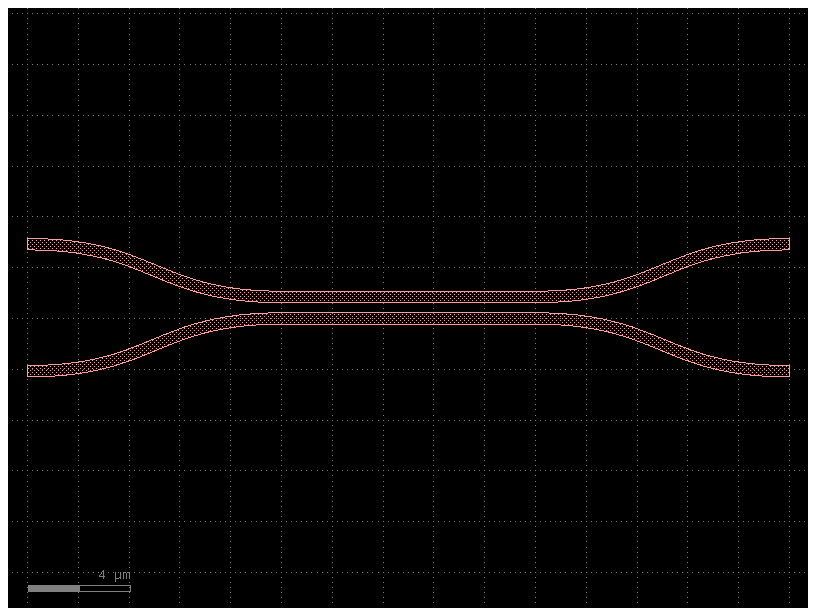

In [5]:
# Parámetros base para la plataforma SOI
w = 0.45         # Ancho de las guías: 450 nm
h = 0.22         # Grosor de las guías: 220 nm
wvl = 1.55       # Longitud de onda: 1550 nm
gap_test = 0.4   # Gap inicial de prueba: 400 nm


# 1. Simulación Sección Transversal (Tidy3D)

coupler_sim = gt.modes.WaveguideCoupler(
    core_width=(w, w),      
    core_thickness=h,
    core_material="si",
    clad_material="sio2",
    gap=gap_test,           
    wavelength=wvl,
    num_modes=2,            
    grid_resolution=20,
    cache_path='.cache/'
)

# Índice de refracción
coupler_sim.plot_index()
plt.title(f"Sección transversal del Acoplador (Gap = {gap_test} um)")
plt.show()

coupler_sim.plot_field(mode_index=0, field_name='Ex', value='real')
plt.title("Modo Fundamenta TE")
plt.show()

coupler_sim.plot_field(mode_index=1, field_name='Ex', value='real')
plt.title("Modo Fundamenta TM")
plt.show()


# 2. Generación del Layout Físico (GDSFactory)

xs_soi = gf.cross_section.strip(width=w)

dc_layout = gf.components.coupler(
    gap=gap_test,
    length=10.0, 
    dx=10.0,  # Longitud de las curvas en S (S-bends)
    dy=5.0,   # Separación vertical de los puertos
    cross_section=xs_soi 
)

dc_layout.plot()

#### Step 2.2 A: Sweep Length (Gap Fijo)

2026-05-25 19:55:51.317 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e0ddedf4d2ad1493.npz.
L_pi (100% acoplo) para Gap 0.4 um: 35.7108 um

--- LONGITUDES EXACTAS PARA SAX ---
k^2 = 0.5  --> L = 17.8554 um
k^2 = 0.3  --> L = 13.1776 um
k^2 = 0.23 --> L = 11.3712 um
k^2 = 0.17 --> L = 9.6618 um
k^2 = 0.05 --> L = 5.1269 um


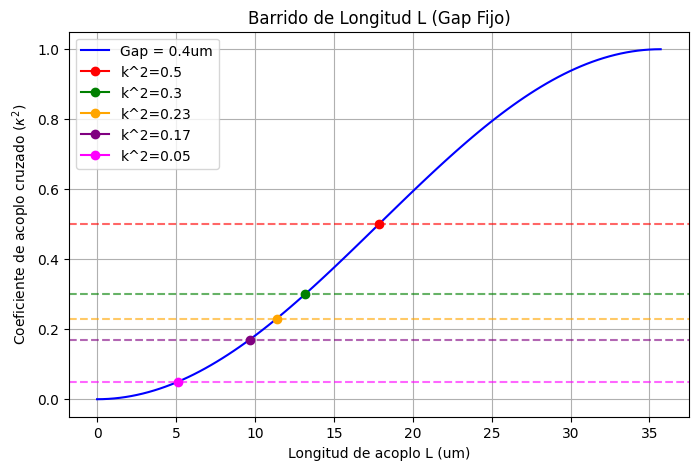

In [6]:
# Parámetros base
w = 0.45
h = 0.22
wvl = 1.55
gap_fijo = 0.4

coupler_L = gt.modes.WaveguideCoupler(
    core_width=(w,w),
    core_thickness=h,
    core_material="si",
    clad_material="sio2",
    gap=gap_fijo,
    wavelength=wvl,
    num_modes=2,
    grid_resolution=20,
    cache_path='.cache/'
)

n_even = coupler_L.n_eff[0].real
n_odd  = coupler_L.n_eff[1].real

L_pi = wvl / (2 * (n_even - n_odd))
print(f"L_pi (100% acoplo) para Gap {gap_fijo} um: {L_pi:.4f} um\n")

# Barrido de Longitud L
L_sweep = np.linspace(0, L_pi, 100)
kappa_cuad = np.sin(np.pi * L_sweep / (2 * L_pi))**2

plt.figure(figsize=(8, 5))
plt.plot(L_sweep, kappa_cuad, color='blue', label=f'Gap = {gap_fijo}um')

objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]
colores = ['red', 'green', 'orange', 'purple', 'fuchsia']

print("--- LONGITUDES EXACTAS PARA SAX ---")
for obj, col in zip(objetivos, colores):
    L_exacta = (2 * L_pi / np.pi) * np.arcsin(np.sqrt(obj))
    print(f"k^2 = {obj:<4} --> L = {L_exacta:.4f} um")
    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(L_exacta, obj, marker='o', color=col, label=f'k^2={obj}')

plt.xlabel('Longitud de acoplo L (um)')
plt.ylabel(r'Coeficiente de acoplo cruzado ($\kappa^2$)')
plt.title('Barrido de Longitud L (Gap Fijo)')
plt.legend()
plt.grid(True)
plt.show()

#### Step 2.2 B: Sweep Gap (Longitud Fija)

/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

2026-05-25 19:55:51.735 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_0c4d7ac9cfaffa37.npz.


/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

2026-05-25 19:55:52.040 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e5843c1a74c1c8a1.npz.


/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

...

2026-05-25 19:55:56.063 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_9bb224a15e7cbbc4.npz.


/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

2026-05-25 19:55:56.477 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_d18367eb2117f27e.npz.


/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=

2026-05-25 19:55:56.937 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8454825389f2ad10.npz.

--- GAPS APROXIMADOS PARA L=10um ---
k^2 = 0.5  --> Gap ~= 0.1836 um
k^2 = 0.3  --> Gap ~= 0.2303 um
k^2 = 0.23 --> Gap ~= 0.2920 um
k^2 = 0.17 --> Gap ~= 0.4757 um
k^2 = 0.05 --> Gap ~= 0.4931 um


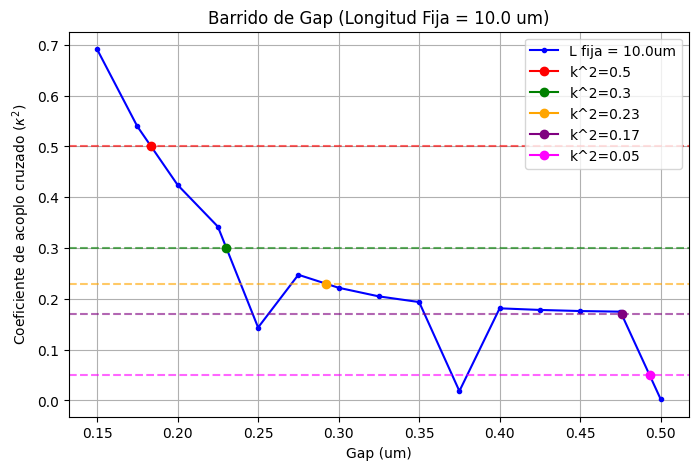

In [7]:
L_fija = 10.0  #
gaps_sweep = np.linspace(0.15, 0.50, 15) 
kappas_gap = []


for g in gaps_sweep:
    c_temp = gt.modes.WaveguideCoupler(
        core_width=(w,w),
        core_thickness=h,
        core_material="si",
        clad_material="sio2",
        gap=float(g),
        wavelength=wvl,
        num_modes=2,
        grid_resolution=20,
        cache_path='.cache/'
    )
    # Extraemos L_pi para cada gap
    ne = c_temp.n_eff[0].real
    no = c_temp.n_eff[1].real
    L_pi_temp = wvl / (2 * (ne - no))
    
    # Calculamos el k^2 para nuestra longitud fija
    k2 = np.sin(np.pi * L_fija / (2 * L_pi_temp))**2
    kappas_gap.append(k2)

kappas_gap = np.array(kappas_gap)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(gaps_sweep, kappas_gap, 'b-', marker='.', label=f'L fija = {L_fija}um')

print("\n--- GAPS APROXIMADOS PARA L=10um ---")
for obj, col in zip(objetivos, colores):
    # Interpolamos para encontrar el Gap exacto 
    # (Invertimos los arrays porque k^2 baja a medida que el gap sube)
    gap_exacto = np.interp(obj, kappas_gap[::-1], gaps_sweep[::-1])
    print(f"k^2 = {obj:<4} --> Gap ~= {gap_exacto:.4f} um")
    
    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(gap_exacto, obj, marker='o', color=col, label=f'k^2={obj}')

plt.xlabel('Gap (um)')
plt.ylabel(r'Coeficiente de acoplo cruzado ($\kappa^2$)')
plt.title(f'Barrido de Gap (Longitud Fija = {L_fija} um)')
plt.legend()
plt.grid(True)
plt.show()

#### Step 3: Extract coupling coefficients

In [8]:
coupler_lengths = {
    0.50: 17.8554,
    0.30: 13.1776,
    0.23: 11.3712,
    0.17: 9.6618,
    0.05: 5.1269
}

print("--- ACOPLADORES DIRECCIONALES ---")
for k2, length in coupler_lengths.items():
    print(f"Divisor de potencia al {int(k2*100):>2}% (k^2={k2}): Longitud = {length} um")

--- ACOPLADORES DIRECCIONALES ---
Divisor de potencia al 50% (k^2=0.5): Longitud = 17.8554 um
Divisor de potencia al 30% (k^2=0.3): Longitud = 13.1776 um
Divisor de potencia al 23% (k^2=0.23): Longitud = 11.3712 um
Divisor de potencia al 17% (k^2=0.17): Longitud = 9.6618 um
Divisor de potencia al  5% (k^2=0.05): Longitud = 5.1269 um


### 3. Cascaded MZI Filter and SAX Model (2 hours)

#### Step 1: Extract the S-matrix from individual components

In [9]:
# Valores de tu simulación del Paso 1 (Modo TE)
n_eff_1550 = 2.3558  
n_g_1550 = 4.2933    
wvl_center = 1.55    



# 1. MATRIZ S DE LA GUÍA DE ONDA (Retraso de Fase)

def waveguide(wl=1.55, length=10.0):
    """
    S-matrix de la guía. Calcula el desfase en función de la longitud 
    y de la longitud de onda, usando la dispersión (n_g).
    """
    dwl = wl - wvl_center
    dn_dwl = - (n_g_1550 - n_eff_1550) / wvl_center
    n_eff_wl = n_eff_1550 + dn_dwl * dwl
    
    # Fase acumulada: phi = (2 * pi * n_eff * L) / lambda
    phase = 2 * jnp.pi * n_eff_wl * length / wl
    amplitude = jnp.exp(1j * phase)
    
    # Matriz S recíproca (2 puertos)
    return sax.reciprocal({
        ("in0", "out0"): amplitude
    })



# 2. MATRIZ S DEL ACOPLADOR DIRECCIONAL (División de Potencia)

def coupler(kappa2=0.5):
    """
    S-matrix del acoplador 2x2.
    kappa2 es la fracción de potencia que cruza al otro brazo.
    """
    tau = jnp.sqrt(1 - kappa2)  # Amplitud transmisión directa (Bar)
    kappa = jnp.sqrt(kappa2)    # Amplitud transmisión cruzada (Cross)
    
    return sax.reciprocal({
        ("in0", "out0"): tau,
        ("in0", "out1"): 1j * kappa,
        ("in1", "out0"): 1j * kappa,
        ("in1", "out1"): tau,
    })


#### Step 2: Define two arms of the MZI with different lengths

In [10]:
# Parámetros del sistema
lambda_c = 1.55       # Longitud de onda central (um)
n_g_1550 = 4.2933     # Tu índice de grupo extraído en el Paso 1

# Queremos un FSR de 40 nm (0.040 um) para procesar canales separados por 20 nm
FSR_objetivo = 0.040  

# Aplicamos la fórmula para calcular el Delta L base
delta_L_base = (lambda_c**2) / (n_g_1550 * FSR_objetivo)

# Definimos las longitudes de los brazos para el modelo SAX
L_top = 50.0  
L_bot = L_top + delta_L_base

print("--- DISEÑO DE LOS BRAZOS DEL MZI S1 ---")
print(f"Objetivo FSR: {FSR_objetivo * 1000} nm")
print(f"Longitud Brazo Superior (L_top): {L_top:.4f} um")
print(f"Longitud Brazo Inferior (L_bot): {L_bot:.4f} um")
print(f"Diferencia exacta (Delta L):     {delta_L_base:.4f} um")

--- DISEÑO DE LOS BRAZOS DEL MZI S1 ---
Objetivo FSR: 40.0 nm
Longitud Brazo Superior (L_top): 50.0000 um
Longitud Brazo Inferior (L_bot): 63.9898 um
Diferencia exacta (Delta L):     13.9898 um


In [11]:
# Parámetros del sistema
lambda_c = 1.55      
n_g_1550 = 4.2933     

# Queremos un FSR de 80 nm (0.080 um) 
FSR_objetivo = 0.080  

# Aplicamos la fórmula para calcular el Delta L base
delta_L_base = (lambda_c**2) / (n_g_1550 * FSR_objetivo)

L_top = 50.0  
L_bot = L_top + delta_L_base

print("--- DISEÑO DE LOS BRAZOS DEL MZI S2 ---")
print(f"Objetivo FSR: {FSR_objetivo * 1000} nm")
print(f"Longitud Brazo Superior (L_top): {L_top:.4f} um")
print(f"Longitud Brazo Inferior (L_bot): {L_bot:.4f} um")
print(f"Diferencia exacta (Delta L):     {delta_L_base:.4f} um")

--- DISEÑO DE LOS BRAZOS DEL MZI S2 ---
Objetivo FSR: 80.0 nm
Longitud Brazo Superior (L_top): 50.0000 um
Longitud Brazo Inferior (L_bot): 56.9949 um
Diferencia exacta (Delta L):     6.9949 um


#### Step 3: Implement the phase condition (Grid Alignment)

In [12]:
lambda_0 = 1.55
n_eff_1550 = 2.3558  

# Ecuación: m = (n_eff * Delta_L) / lambda_0
m_flotante = (n_eff_1550 * delta_L_base) / lambda_0

# Forzamos a que 'm' sea un número entero puro
m_entero = np.round(m_flotante)

# Recalculamos el Delta L  usando el 'm' entero
delta_L_exact = (m_entero * lambda_0) / n_eff_1550

print("--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---")
print(f"1. Delta L base (solo FSR):        {delta_L_base:.4f} um")
print(f"2. Orden de interferencia 'm':     {m_flotante:.4f} -> Redondeado a {int(m_entero)}")
print(f"3. Delta L EXACTO (Fase perfecta): {delta_L_exact:.4f} um")

L_top = 50.0  
L_bot = L_top + delta_L_exact

--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---
1. Delta L base (solo FSR):        6.9949 um
2. Orden de interferencia 'm':     10.6314 -> Redondeado a 11
3. Delta L EXACTO (Fase perfecta): 7.2375 um


#### Step 4: Simulate transmission spectrum and confirm FSR

<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
/var/folders/z4/phjdynmj6xzflp_j32ssw0b00000gp/T/ipykernel_24094/1151104500.py:57: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"Espectro del MZI Básico (FSR = 40 nm) - $\Delta L$ = {delta_L_exact:.4f} um")


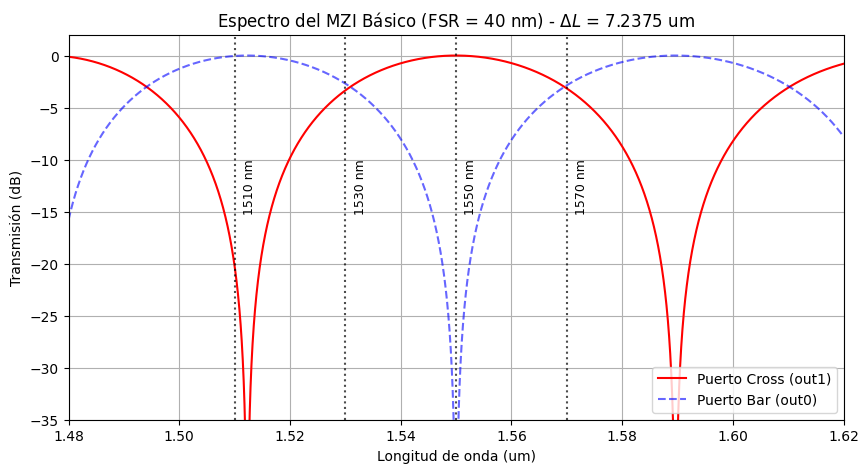

In [13]:
# 1. Definimos la red de conexiones (Netlist) del MZI
mzi_netlist = {
    "instances": {
        "c_in": "coupler",
        "c_out": "coupler",
        "wg_top": "waveguide",
        "wg_bot": "waveguide",
    },
    "connections": {
        "c_in,out0": "wg_top,in0",
        "c_in,out1": "wg_bot,in0",
        "wg_top,out0": "c_out,in0",
        "wg_bot,out0": "c_out,in1",
    },
    "ports": {
        "in0": "c_in,in0",
        "out0": "c_out,out0",
        "out1": "c_out,out1",
    }
}

# 2. Compilamos el circuito con SAX
mzi_circuit, _ = sax.circuit(
    netlist=mzi_netlist, 
    models={"waveguide": waveguide, "coupler": coupler}
)

# 3. Barrido de simulación (Alta resolución para ver bien los picos en dB)
wvl_sweep = jnp.linspace(1.48, 1.62, 5000)

# Simulamos inyectando luz por el puerto 'in0', usando nuestro L_top y L_bot exactos
S = mzi_circuit(
    wl=wvl_sweep,
    wg_top={"length": L_top},
    wg_bot={"length": L_bot},  # Usamos el L_bot con el ajuste fino de fase
    c_in={"kappa2": 0.5},      # MZI básico usa acopladores 50/50
    c_out={"kappa2": 0.5}
)

# 4. Extraemos y convertimos a Decibelios (dB)
T_bar_dB = 10 * jnp.log10(jnp.abs(S["in0", "out0"])**2 + 1e-12)
T_cross_dB = 10 * jnp.log10(jnp.abs(S["in0", "out1"])**2 + 1e-12)

# 5. Visualización 
plt.figure(figsize=(10, 5))
plt.plot(wvl_sweep, T_cross_dB, color='red', label="Puerto Cross (out1)")
plt.plot(wvl_sweep, T_bar_dB, color='blue', linestyle='--', alpha=0.6, label="Puerto Bar (out0)")

# Marcamos los canales CWDM teóricos (1510, 1530, 1550, 1570 nm)
canales_cwdm = [1.510, 1.530, 1.550, 1.570]
for ch in canales_cwdm:
    plt.axvline(ch, color='black', linestyle=':', alpha=0.7)
    plt.text(ch + 0.0015, -15, f"{ch*1000:.0f} nm", rotation=90, fontsize=9)

plt.xlabel("Longitud de onda (um)")
plt.ylabel("Transmisión (dB)")
plt.title(f"Espectro del MZI Básico (FSR = 40 nm) - $\Delta L$ = {delta_L_exact:.4f} um")
plt.ylim(-35, 2)
plt.xlim(1.48, 1.62)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Step 5 & 6: Cascaded MZI Model (Flat-top Filter) and Validate spectral alignment of outputs (Achieve transmission spectrum as shown in Figure 6(a)).

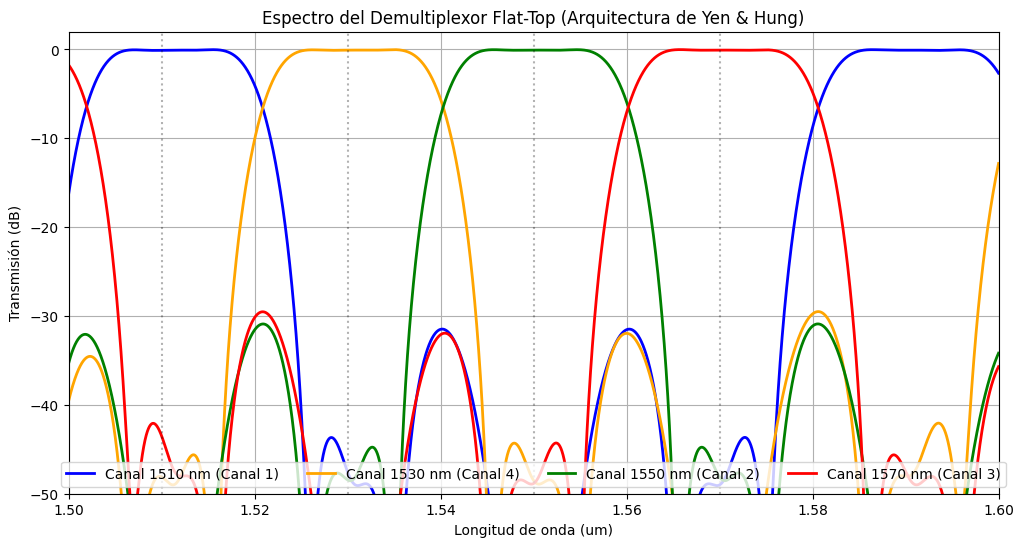

In [14]:
lambda_0 = 1.55
n_eff_sim = 2.32717 
n_g_1550 = 4.2933    


# 1. CÁLCULO FÍSICO DE DELAY LINES

# S1 (FSR = 40 nm)
FSR_S1 = 0.040
dL_S1 = (lambda_0**2) / (n_g_1550 * FSR_S1)
L2_S1 = 50.0            # Brazo corto
L1_S1 = L2_S1 + dL_S1   # Brazo largo

# S2 (FSR = 80 nm -> Requiere exactamente la MITAD de Delta L)
FSR_S2 = 0.080
dL_S2 = (lambda_0**2) / (n_g_1550 * FSR_S2)
L2_S2 = 50.0            
L1_S2 = L2_S2 + dL_S2   

# Desfases Ópticos (pi y 0.5*pi)
L_pi = lambda_0 / (2 * n_eff_sim)
L_half_pi = 0.5 * L_pi



# 2. DEFINICIÓN DE MODELOS SAX

def waveguide(wl=1.55, length=10.0):
    dwl = wl - lambda_0
    dn_dwl = - (n_g_1550 - n_eff_sim) / lambda_0
    n_eff_wl = n_eff_sim + dn_dwl * dwl
    phase = 2 * jnp.pi * n_eff_wl * length / wl
    return sax.reciprocal({("in0", "out0"): jnp.exp(1j * phase)})

def coupler(kappa2=0.5):
    tau = jnp.sqrt(1 - kappa2)
    kappa = jnp.sqrt(kappa2)
    return sax.reciprocal({
        ("in0", "out0"): tau, ("in0", "out1"): 1j * kappa,
        ("in1", "out0"): 1j * kappa, ("in1", "out1"): tau,
    })

# Wrappers para S1
def wg_L1_S1(wl=1.55): return waveguide(wl=wl, length=L1_S1)
def wg_L2_S1(wl=1.55): return waveguide(wl=wl, length=L2_S1)
def wg_2L1_S1(wl=1.55): return waveguide(wl=wl, length=2*L1_S1)
def wg_2L2_S1(wl=1.55): return waveguide(wl=wl, length=2*L2_S1)
def wg_2L1_pi_S1(wl=1.55): return waveguide(wl=wl, length=2*L1_S1 + L_pi)

# Wrappers para S2 NORMAL
def wg_L1_S2(wl=1.55): return waveguide(wl=wl, length=L1_S2)
def wg_L2_S2(wl=1.55): return waveguide(wl=wl, length=L2_S2)
def wg_2L1_S2(wl=1.55): return waveguide(wl=wl, length=2*L1_S2)
def wg_2L2_S2(wl=1.55): return waveguide(wl=wl, length=2*L2_S2)

# Wrappers para S2 SHIFTED
def wg_L1_shift_S2(wl=1.55): return waveguide(wl=wl, length=L1_S2 + L_half_pi)
def wg_2L1_shift_S2(wl=1.55): return waveguide(wl=wl, length=2*L1_S2 + 2*L_half_pi)

base_models = {
    "wg_L1_S1": wg_L1_S1, "wg_L2_S1": wg_L2_S1, "wg_2L1_S1": wg_2L1_S1, "wg_2L2_S1": wg_2L2_S1, "wg_2L1_pi_S1": wg_2L1_pi_S1,
    "wg_L1_S2": wg_L1_S2, "wg_L2_S2": wg_L2_S2, "wg_2L1_S2": wg_2L1_S2, "wg_2L2_S2": wg_2L2_S2,
    "wg_L1_shift_S2": wg_L1_shift_S2, "wg_2L1_shift_S2": wg_2L1_shift_S2,
    "c_50": lambda: coupler(0.50), "c_30": lambda: coupler(0.30), 
    "c_23": lambda: coupler(0.23), "c_17": lambda: coupler(0.17), "c_05": lambda: coupler(0.05)
}




# 3. NETLISTS DE LOS BLOQUES 

s1_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_17", "c3": "c_23", "c4": "c_05",
        "w_t1": "wg_L1_S1", "w_b1": "wg_L2_S1",
        "w_t2": "wg_2L2_S1", "w_b2": "wg_2L1_S1",
        "w_t3": "wg_2L2_S1", "w_b3": "wg_2L1_pi_S1",
    },
    "connections": {
        "c1,out0": "w_t1,in0", "c1,out1": "w_b1,in0", "w_t1,out0": "c2,in0", "w_b1,out0": "c2,in1",
        "c2,out0": "w_t2,in0", "c2,out1": "w_b2,in0", "w_t2,out0": "c3,in0", "w_b2,out0": "c3,in1",
        "c3,out0": "w_t3,in0", "c3,out1": "w_b3,in0", "w_t3,out0": "c4,in0", "w_b3,out0": "c4,in1",
    },
    "ports": {"in_up": "c1,in0", "in_down": "c1,in1", "out_up": "c4,out0", "out_down": "c4,out1"}
}
S1_model, _ = sax.circuit(netlist=s1_netlist, models=base_models)

s2_norm_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_30", "c3": "c_05",
        "w_t1": "wg_L1_S2", "w_b1": "wg_L2_S2",
        "w_t2": "wg_2L2_S2", "w_b2": "wg_2L1_S2",
    },
    "connections": {
        "c1,out0": "w_t1,in0", "c1,out1": "w_b1,in0", "w_t1,out0": "c2,in0", "w_b1,out0": "c2,in1",
        "c2,out0": "w_t2,in0", "c2,out1": "w_b2,in0", "w_t2,out0": "c3,in0", "w_b2,out0": "c3,in1",
    },
    "ports": {"in_up": "c1,in0", "in_down": "c1,in1", "out_up": "c3,out0", "out_down": "c3,out1"}
}
S2_norm_model, _ = sax.circuit(netlist=s2_norm_netlist, models=base_models)

s2_shift_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_30", "c3": "c_05",
        "w_t1": "wg_L1_shift_S2", "w_b1": "wg_L2_S2",
        "w_t2": "wg_2L2_S2", "w_b2": "wg_2L1_shift_S2",
    },
    "connections": {
        "c1,out0": "w_t1,in0", "c1,out1": "w_b1,in0", "w_t1,out0": "c2,in0", "w_b1,out0": "c2,in1",
        "c2,out0": "w_t2,in0", "c2,out1": "w_b2,in0", "w_t2,out0": "c3,in0", "w_b2,out0": "c3,in1",
    },
    "ports": {"in_up": "c1,in0", "in_down": "c1,in1", "out_up": "c3,out0", "out_down": "c3,out1"}
}
S2_shift_model, _ = sax.circuit(netlist=s2_shift_netlist, models=base_models)




# 4. RUTEO FÍSICO EXACTO DEL ÁRBOL

tree_netlist = {
    "instances": {
        "s1_1": "S1", "s1_2": "S1", "s1_3": "S1",
        "s2_1_n": "S2_norm", "s2_3_n": "S2_norm", "s2_4_n": "S2_norm",
        "s2_2_s": "S2_shift", "s2_5_s": "S2_shift", "s2_6_s": "S2_shift"
    },
    "connections": {
        # RUTA 1 y 2 (Rama Superior)
        "s1_1,out_up": "s1_2,in_down",
        "s1_2,out_up": "s2_1_n,in_down",
        "s2_1_n,out_up": "s2_3_n,in_down",       # Hacia s2_3_n
        "s2_1_n,out_down": "s2_4_n,in_up",       # Hacia s2_4_n
        
        # RUTA 3 y 4 (Rama Inferior)
        "s1_1,out_down": "s1_3,in_down",
        "s1_3,out_down": "s2_2_s,in_up",
        "s2_2_s,out_up": "s2_5_s,in_down",       # Hacia s2_5_s
        "s2_2_s,out_down": "s2_6_s,in_up",       # Hacia s2_6_s
    },
    "ports": {
        "in_main": "s1_1,in_down",
        "out_1510": "s2_3_n,out_up",    # RUTA 1
        "out_1550": "s2_4_n,out_up",    # RUTA 2
        "out_1570": "s2_5_s,out_down",  # RUTA 3
        "out_1530": "s2_6_s,out_down",  # RUTA 4
    }
}

tree_circuit, _ = sax.circuit(netlist=tree_netlist, models={"S1": S1_model, "S2_norm": S2_norm_model, "S2_shift": S2_shift_model})




# 5. SIMULACIÓN Y VISUALIZACIÓN (1500 a 1600 nm, de 0 a -50 dB)

wvl_sweep = jnp.linspace(1.50, 1.60, 5000)
S_tree = tree_circuit(wl=wvl_sweep)

T_1510 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1510"])**2 + 1e-12)
T_1530 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1530"])**2 + 1e-12)
T_1550 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1550"])**2 + 1e-12)
T_1570 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1570"])**2 + 1e-12)

plt.figure(figsize=(12, 6))
plt.plot(wvl_sweep, T_1510, label="Canal 1510 nm (Canal 1)", color='blue', linewidth=2)
plt.plot(wvl_sweep, T_1530, label="Canal 1530 nm (Canal 4)", color='orange', linewidth=2)
plt.plot(wvl_sweep, T_1550, label="Canal 1550 nm (Canal 2)", color='green', linewidth=2)
plt.plot(wvl_sweep, T_1570, label="Canal 1570 nm (Canal 3)", color='red', linewidth=2)

canales = [1.51, 1.53, 1.55, 1.57]
for c in canales:
    plt.axvline(c, color='black', alpha=0.3, linestyle=':')

plt.xlabel("Longitud de onda (um)")
plt.ylabel("Transmisión (dB)")
plt.title("Espectro del Demultiplexor Flat-Top (Arquitectura de Yen & Hung)")
plt.ylim(-50, 2)
plt.xlim(1.50, 1.60)
plt.legend(loc="lower center", ncol=4)
plt.grid(True)
plt.show()

## PART II. Filter and die layout

### 4. Layout of the CWDM (de)multiplexer filter employing GDSFactory+ (1.5 Hours)

#### Step 1: Create the schematics for S1 and S2 and connect them to generate the layout of the CWDM (de)multiplexer filter employing GDSFactory+.

2026-05-25 19:56:02.028 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


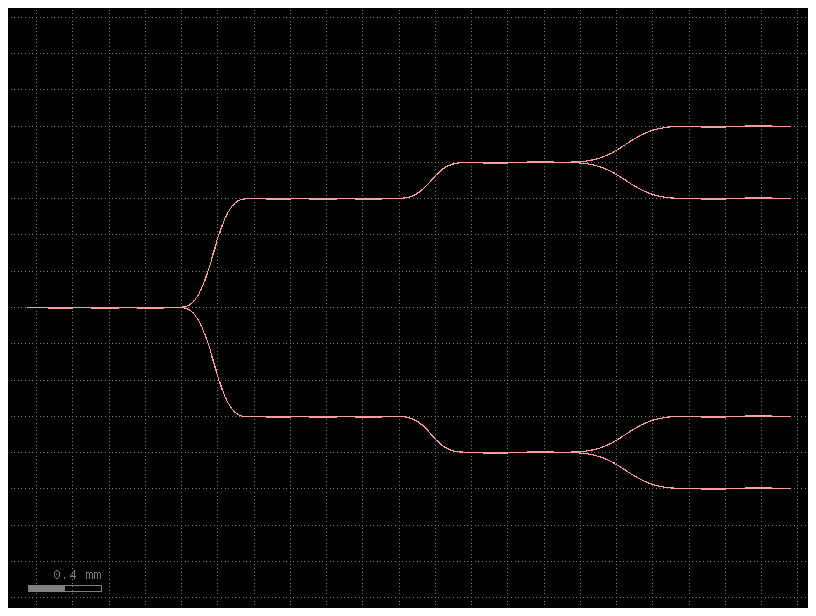

In [15]:
gf.clear_cache()
# 1. Definición de bloques base (Esquemáticos de S1 y S2) 

@gf.cell
def coupler_custom(length=10.0, gap=0.4): 
    """Acoplador direccional paramétrico.""" 
    return gf.components.coupler(length=length, gap=gap, dx=50.0) 

@gf.cell
def S1_block(): 
    """Esquemático del bloque S1 (3 etapas MZI, 4 acopladores).""" 
    c = gf.Component() 
    
    # Instanciamos los 4 acopladores con los coeficientes del diseño 
    c1 = c << coupler_custom(length=15.0) # 0.5 
    c2 = c << coupler_custom(length=6.0)  # 0.17 
    c3 = c << coupler_custom(length=8.0)  # 0.23 
    c4 = c << coupler_custom(length=3.0)  # 0.05 
    
    # Posicionamiento horizontal 
    c2.dmovex(250) 
    c3.dmovex(500) 
    c4.dmovex(750) 
    
    # Conexiones internas  
    gf.routing.route_single_sbend(c, port1=c1.ports["o3"], port2=c2.ports["o2"]) 
    gf.routing.route_single_sbend(c, port1=c1.ports["o4"], port2=c2.ports["o1"]) 
    
    gf.routing.route_single_sbend(c, port1=c2.ports["o3"], port2=c3.ports["o2"]) 
    gf.routing.route_single_sbend(c, port1=c2.ports["o4"], port2=c3.ports["o1"]) 
    
    gf.routing.route_single_sbend(c, port1=c3.ports["o3"], port2=c4.ports["o2"]) 
    gf.routing.route_single_sbend(c, port1=c3.ports["o4"], port2=c4.ports["o1"]) 
    
    # Puertos 
    c.add_port("in_up", port=c1.ports["o2"]) 
    c.add_port("in_down", port=c1.ports["o1"]) 
    c.add_port("out_up", port=c4.ports["o3"]) 
    c.add_port("out_down", port=c4.ports["o4"]) 
    
    return c 

@gf.cell
def S2_block(shifted=False): 
    """Esquemático del bloque S2 (2 etapas MZI, 3 acopladores).""" 
    name = "S2_shift" if shifted else "S2_norm" 
    c = gf.Component(name) 
    
    c1 = c << coupler_custom(length=15.0) # 0.5 
    c2 = c << coupler_custom(length=10.0) # 0.3 
    c3 = c << coupler_custom(length=3.0)  # 0.05 
    
    c2.dmovex(250) 
    c3.dmovex(500) 
    
    # Conexiones internas 
    gf.routing.route_single_sbend(c, port1=c1.ports["o3"], port2=c2.ports["o2"]) 
    gf.routing.route_single_sbend(c, port1=c1.ports["o4"], port2=c2.ports["o1"]) 
    
    gf.routing.route_single_sbend(c, port1=c2.ports["o3"], port2=c3.ports["o2"]) 
    gf.routing.route_single_sbend(c, port1=c2.ports["o4"], port2=c3.ports["o1"]) 
    
    # Puertos 
    c.add_port("in_up", port=c1.ports["o2"]) 
    c.add_port("in_down", port=c1.ports["o1"]) 
    c.add_port("out_up", port=c3.ports["o3"]) 
    c.add_port("out_down", port=c3.ports["o4"]) 
    
    return c 


# 2. Conexión del Árbol (Demultiplexor Completo) 

@gf.cell 
def CWDM_filter_layout(): 
    main = gf.Component("CWDM_Filter") 
    
    # Instancias del árbol  
    s1_1 = main << S1_block() 
    s1_2 = main << S1_block() 
    s1_3 = main << S1_block() 
    
    # Rama Superior (Norm) 
    s2_1 = main << S2_block(shifted=False) 
    s2_3 = main << S2_block(shifted=False) 
    s2_4 = main << S2_block(shifted=False) 
    
    # Rama Inferior (Shifted) 
    s2_2 = main << S2_block(shifted=True) 
    s2_5 = main << S2_block(shifted=True) 
    s2_6 = main << S2_block(shifted=True) 
    
    # Posicionamiento del Árbol (dx, dy grandes para permitir curvas suaves) 
    dx, dy = 1200, 600 
    
    s1_2.dmove((dx, dy)) 
    s1_3.dmove((dx, -dy)) 
    
    s2_1.dmove((2*dx, dy + 200)) 
    s2_2.dmove((2*dx, -dy - 200)) 
    
    s2_3.dmove((3*dx, dy + 400)) 
    s2_4.dmove((3*dx, dy)) 
    
    s2_5.dmove((3*dx, -dy)) 
    s2_6.dmove((3*dx, -dy - 400)) 
    
    # CONEXIONES 
    
    # RUTA 1 y 2 (Rama Superior) 
    gf.routing.route_single_sbend(main, port1=s1_1.ports["out_up"], port2=s1_2.ports["in_down"]) 
    gf.routing.route_single_sbend(main, port1=s1_2.ports["out_up"], port2=s2_1.ports["in_down"]) 
    gf.routing.route_single_sbend(main, port1=s2_1.ports["out_up"], port2=s2_3.ports["in_down"]) # R1 -> 1570nm 
    gf.routing.route_single_sbend(main, port1=s2_1.ports["out_down"], port2=s2_4.ports["in_up"]) # R2 -> 1530nm 
    
    # RUTA 3 y 4 (Rama Inferior) 
    gf.routing.route_single_sbend(main, port1=s1_1.ports["out_down"], port2=s1_3.ports["in_down"]) 
    gf.routing.route_single_sbend(main, port1=s1_3.ports["out_down"], port2=s2_2.ports["in_up"]) 
    gf.routing.route_single_sbend(main, port1=s2_2.ports["out_up"], port2=s2_5.ports["in_down"]) # R3 -> 1510nm 
    gf.routing.route_single_sbend(main, port1=s2_2.ports["out_down"], port2=s2_6.ports["in_up"]) # R4 -> 1550nm 
    
    # Puertos finales del chip 
    main.add_port("In", port=s1_1.ports["in_up"]) 
    main.add_port("Out_1510", port=s2_3.ports["out_up"]) 
    main.add_port("Out_1550", port=s2_4.ports["out_up"]) 
    main.add_port("Out_1570", port=s2_5.ports["out_down"]) 
    main.add_port("Out_1530", port=s2_6.ports["out_down"]) 
    
    return main 


c = CWDM_filter_layout() 
c.show() 
c.plot()

#### Step 2 & 3: Define the layout of directional couplers, waveguides, and phase shifters as needed.

2026-05-25 19:56:02.182 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/cachetools/_cached.py:185: UserWarning: bend_euler angle should be 90 or 180. Got -90. Use bend_euler_all_angle instead.
  v = func(*args, **kwargs)
/Users/mariajulvebenages/Desktop/MASTER PIC/Design/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 1.0} ignored for cross_section 'strip'
  x = gf.get_cross_section(cross_section, width=width or x.width)


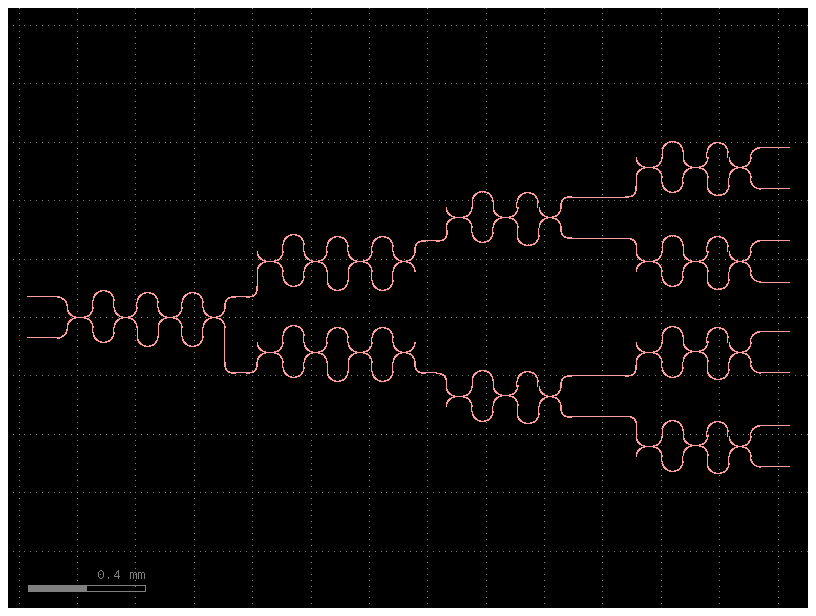

In [16]:
gf.clear_cache()

# 1. PARÁMETROS DEL FILTRO 
dL_S1 = 13.99      
dL_S2 = 6.99       
L_pi = 0.33        
L_half_pi = 0.16   
R_BEND = 35.0      

L2_S1 = 0.0
L1_S1 = dL_S1
L2_S2 = 0.0
L1_S2 = dL_S2


xs = "strip" # Cross-section global

# 2. ACOPLADOR MANUAL (Salidas Verticales)
@gf.cell
def coupler(length=10.0, gap=0.4, R=R_BEND):
    c = gf.Component()
    s_top = c << gf.components.straight(length=length, cross_section=xs)
    s_bot = c << gf.components.straight(length=length, cross_section=xs)
    
    dist = gap + 0.5 
    s_top.dmovey(dist / 2)
    s_bot.dmovey(-dist / 2)
    
    bin_top = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
    bout_top = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
    bin_bot = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    bout_bot = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    
    bin_top.connect("o2", s_top.ports["o1"])
    bout_top.connect("o1", s_top.ports["o2"])
    bin_bot.connect("o2", s_bot.ports["o1"])
    bout_bot.connect("o1", s_bot.ports["o2"])
    
    c.add_port("o1", port=bin_top.ports["o1"])
    c.add_port("o2", port=bin_bot.ports["o1"])
    c.add_port("o3", port=bout_top.ports["o2"])
    c.add_port("o4", port=bout_bot.ports["o2"])
    return c

#3. BRAZO MZI 
@gf.cell
def mzi_arm(length_horizontal=2.0, extra_length=0.0, is_top=True, R=R_BEND):
    c = gf.Component()
    L_vert = 15.0 + (extra_length / 2.0)
    
    sv1 = c << gf.components.straight(length=L_vert, cross_section=xs)
    sh  = c << gf.components.straight(length=length_horizontal, cross_section=xs)
    sv2 = c << gf.components.straight(length=L_vert, cross_section=xs)
    
    if is_top:
        b1 = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
        b2 = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    else:
        b1 = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
        b2 = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
        
    b1.connect("o1", sv1.ports["o2"])
    sh.connect("o1", b1.ports["o2"])
    b2.connect("o1", sh.ports["o2"])
    sv2.connect("o1", b2.ports["o2"])
    
    c.add_port("o1", port=sv1.ports["o1"])
    c.add_port("o2", port=sv2.ports["o2"])
    return c

# 4. BLOQUES S1 Y S2 
@gf.cell
def S1_block(): 
    c = gf.Component() 
    c1 = c << coupler(length=17.8554) 
    c2 = c << coupler(length=9.6618)  
    c3 = c << coupler(length=11.3712) 
    c4 = c << coupler(length=5.1269)  
    
    LH = 2.0 
    
    t1 = c << mzi_arm(LH, L1_S1, True)
    b1 = c << mzi_arm(LH, L2_S1, False)
    t1.connect("o1", c1.ports["o3"]); b1.connect("o1", c1.ports["o4"])
    c2.connect("o1", t1.ports["o2"])
    
    t2 = c << mzi_arm(LH, 2 * L2_S1, True)
    b2 = c << mzi_arm(LH, 2 * L1_S1, False)
    t2.connect("o1", c2.ports["o3"]); b2.connect("o1", c2.ports["o4"])
    c3.connect("o1", t2.ports["o2"])
    
    t3 = c << mzi_arm(LH, 2 * L2_S1, True)
    b3 = c << mzi_arm(LH, 2 * L1_S1 + L_pi, False)
    t3.connect("o1", c3.ports["o3"]); b3.connect("o1", c3.ports["o4"])
    c4.connect("o1", t3.ports["o2"])
    
    c.add_port("in_up", port=c1.ports["o1"]) 
    c.add_port("in_down", port=c1.ports["o2"]) 
    c.add_port("out_up", port=c4.ports["o3"]) 
    c.add_port("out_down", port=c4.ports["o4"]) 
    return c 

@gf.cell
def S2_block(shifted=False): 
    c = gf.Component() 
    c1 = c << coupler(length=17.8554) 
    c2 = c << coupler(length=13.1776) 
    c3 = c << coupler(length=5.1269)  
    
    LH = 2.0
    s1, s2 = (L_half_pi, L_pi) if shifted else (0.0, 0.0)

    t1 = c << mzi_arm(LH, L1_S2 + s1, True)
    b1 = c << mzi_arm(LH, L2_S2, False)
    t1.connect("o1", c1.ports["o3"]); b1.connect("o1", c1.ports["o4"])
    c2.connect("o1", t1.ports["o2"])
    
    t2 = c << mzi_arm(LH, 2 * L2_S2, True)
    b2 = c << mzi_arm(LH, 2 * L1_S2 + s2, False)
    t2.connect("o1", c2.ports["o3"]); b2.connect("o1", c2.ports["o4"])
    c3.connect("o1", t2.ports["o2"])
    
    c.add_port("in_up", port=c1.ports["o1"]) 
    c.add_port("in_down", port=c1.ports["o2"]) 
    c.add_port("out_up", port=c3.ports["o3"]) 
    c.add_port("out_down", port=c3.ports["o4"]) 
    return c 

@gf.cell 
def CWDM_filter_layout(): 
    main = gf.Component("CWDM_CORE") 
    
    s1_1, s1_2, s1_3 = main << S1_block(), main << S1_block(), main << S1_block()
    s2_1, s2_3, s2_4 = main << S2_block(False), main << S2_block(False), main << S2_block(False)
    s2_2, s2_5, s2_6 = main << S2_block(True), main << S2_block(True), main << S2_block(True)
    
    dx, dy = 650, 120
    offset_y = 70.9 
    
    s1_2.dmove((dx, dy + offset_y))
    s2_1.dmove((2*dx, dy + 150 + offset_y))
    s2_3.dmove((3*dx, dy + 320 + offset_y))
    s2_4.dmove((3*dx, dy + offset_y))
    
    s1_3.dmove((dx, -dy))
    s2_2.dmove((2*dx, -dy - 150))
    s2_5.dmove((3*dx, -dy))
    s2_6.dmove((3*dx, -dy - 320))
    
    # ENTRADAS
    x_input = s1_1.ports["in_up"].center[0] - R_BEND - 100.0
    
    b_in_up = main << gf.components.bend_circular(angle=90, radius=R_BEND, cross_section=xs)
    b_in_up.connect("o1", s1_1.ports["in_up"])
    st_in_up = main << gf.components.straight(length=abs(b_in_up.ports["o2"].center[0] - x_input), cross_section=xs)
    st_in_up.connect("o1", b_in_up.ports["o2"])
    main.add_port("in_up", port=st_in_up.ports["o2"])
    
    b_in_dn = main << gf.components.bend_circular(angle=-90, radius=R_BEND, cross_section=xs)
    b_in_dn.connect("o1", s1_1.ports["in_down"])
    st_in_dn = main << gf.components.straight(length=abs(b_in_dn.ports["o2"].center[0] - x_input), cross_section=xs)
    st_in_dn.connect("o1", b_in_dn.ports["o2"])
    main.add_port("in_down", port=st_in_dn.ports["o2"])
    
    # SALIDAS
    max_x = max([
        s2_3.ports["out_up"].center[0], s2_3.ports["out_down"].center[0],
        s2_4.ports["out_up"].center[0], s2_4.ports["out_down"].center[0],
        s2_5.ports["out_up"].center[0], s2_5.ports["out_down"].center[0],
        s2_6.ports["out_up"].center[0], s2_6.ports["out_down"].center[0]
    ])
    x_output = max_x + R_BEND + 100.0
    
    salidas = [
        (s2_3.ports["out_up"], "out_1510"), (s2_3.ports["out_down"], "out_s23_down"),
        (s2_4.ports["out_up"], "out_1550"), (s2_4.ports["out_down"], "out_s24_down"),
        (s2_5.ports["out_up"], "out_s25_up"), (s2_5.ports["out_down"], "out_1570"),
        (s2_6.ports["out_up"], "out_s26_up"), (s2_6.ports["out_down"], "out_1530")
    ]
    
    for port, name in salidas:
        angle = -90 if port.orientation == 90 else 90
        b = main << gf.components.bend_circular(angle=angle, radius=R_BEND, cross_section=xs)
        b.connect("o1", port)
        s = main << gf.components.straight(length=abs(x_output - b.ports["o2"].center[0]), cross_section=xs)
        s.connect("o1", b.ports["o2"])
        main.add_port(name, port=s.ports["o2"])

    # RUTEO INTERNO
    gf.routing.route_single(main, s1_1.ports["out_up"], s1_2.ports["in_down"], radius=R_BEND, cross_section=xs)
    gf.routing.route_single(main, s1_1.ports["out_down"], s1_3.ports["in_down"], radius=R_BEND, cross_section=xs)
    conex = [
        (s1_2.ports["out_up"], s2_1.ports["in_down"]), (s2_1.ports["out_up"], s2_3.ports["in_down"]),
        (s2_1.ports["out_down"], s2_4.ports["in_up"]), (s1_3.ports["out_down"], s2_2.ports["in_up"]),
        (s2_2.ports["out_up"], s2_5.ports["in_down"]), (s2_2.ports["out_down"], s2_6.ports["in_up"])
    ]
    for p1, p2 in conex:
        gf.routing.route_single(main, p1, p2, radius=R_BEND, cross_section=xs)
    
    return main 

c = CWDM_filter_layout() 
c.show()
c.plot()


### 5. Layout of the Whole Die and Test Structures, finalize the full die layout with test structures for fabrication.

In [17]:
dL_S1 = 13.99      
dL_S2 = 6.99       
L_pi = 0.33        
L_half_pi = 0.16   
R_BEND = 35.0      

L2_S1 = 0.0
L1_S1 = dL_S1
L2_S2 = 0.0
L1_S2 = dL_S2

xs = "strip" # Cross-section global


# DEFINICIÓN DEL DIE (Marco del chip)
@gf.cell
def die(dieL = 4500, dieW = 6500, border = 250, layer_box = "FLOORPLAN"):
    # Si la capa "FLOORPLAN" te da error por el PDK, cámbiala a (50, 0)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2, dieL-border*2), layer=layer_box)).dmovex(border).dmovey(border)
    
    # Resta booleana para dejar solo el marco
    try:
        box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    except:
        # Fallback por si la versión de KFactory no soporta gf.boolean directamente
        pass 
        
    # Añadimos puerto de origen
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    return box

2026-05-25 19:56:02.543 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


PosixPath('CWDM_Filter_Layout_Test_Structures.gds')

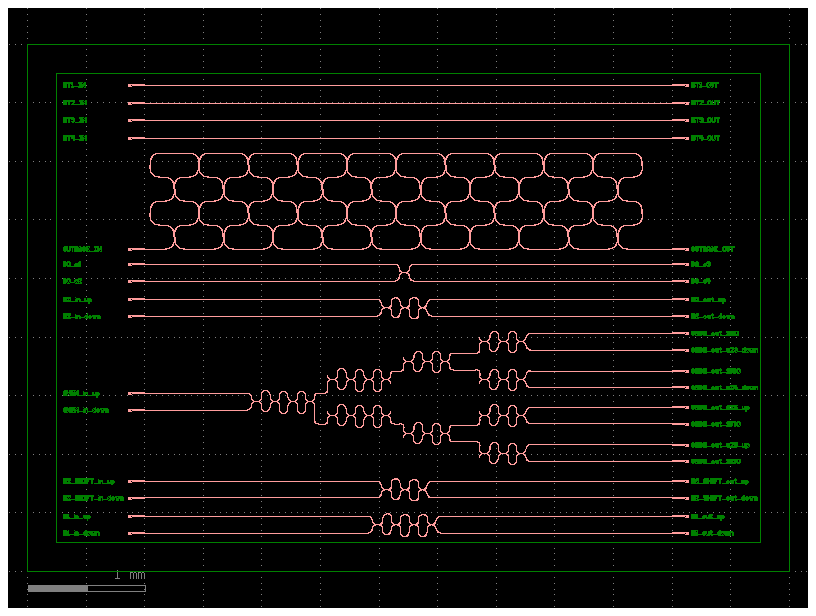

In [18]:
from upvfab.sin300.cband import PDK, cells

gf.clear_cache()

# PARÁMETROS GLOBALES

dL_S1 = 13.99      
dL_S2 = 6.99       
L_pi = 0.33        
R_BEND = 35.0      
L_half_pi = 0.16   

L2_S1 = 0.0
L1_S1 = dL_S1
L2_S2 = 0.0
L1_S2 = dL_S2

xs = "strip"



# 1. DEFINICIÓN DEL DIE Y COMPONENTES

@gf.cell
def die(dieL = 4500, dieW = 6500, border = 250, layer_box = "FLOORPLAN"):
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2, dieL-border*2), layer=layer_box)).dmovex(border).dmovey(border)
    try:
        box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    except:
        pass 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    return box

@gf.cell
def coupler(length=10.0, gap=0.4, R=R_BEND):
    c = gf.Component()
    s_top = c << gf.components.straight(length=length, cross_section=xs)
    s_bot = c << gf.components.straight(length=length, cross_section=xs)
    dist = gap + 0.5 
    s_top.dmovey(dist / 2)
    s_bot.dmovey(-dist / 2)
    bin_top = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
    bout_top = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
    bin_bot = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    bout_bot = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    bin_top.connect("o2", s_top.ports["o1"])
    bout_top.connect("o1", s_top.ports["o2"])
    bin_bot.connect("o2", s_bot.ports["o1"])
    bout_bot.connect("o1", s_bot.ports["o2"])
    c.add_port("o1", port=bin_top.ports["o1"])
    c.add_port("o2", port=bin_bot.ports["o1"])
    c.add_port("o3", port=bout_top.ports["o2"])
    c.add_port("o4", port=bout_bot.ports["o2"])
    return c

@gf.cell
def mzi_arm(length_horizontal=2.0, extra_length=0.0, is_top=True, R=R_BEND):
    c = gf.Component()
    L_vert = 15.0 + (extra_length / 2.0)
    sv1 = c << gf.components.straight(length=L_vert, cross_section=xs)
    sh  = c << gf.components.straight(length=length_horizontal, cross_section=xs)
    sv2 = c << gf.components.straight(length=L_vert, cross_section=xs)
    if is_top:
        b1 = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
        b2 = c << gf.components.bend_circular(angle=-90, radius=R, cross_section=xs)
    else:
        b1 = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
        b2 = c << gf.components.bend_circular(angle=90, radius=R, cross_section=xs)
    b1.connect("o1", sv1.ports["o2"])
    sh.connect("o1", b1.ports["o2"])
    b2.connect("o1", sh.ports["o2"])
    sv2.connect("o1", b2.ports["o2"])
    c.add_port("o1", port=sv1.ports["o1"])
    c.add_port("o2", port=sv2.ports["o2"])
    return c

@gf.cell
def S1_block(): 
    c = gf.Component() 
    c1 = c << coupler(length=17.8554); c2 = c << coupler(length=9.6618)  
    c3 = c << coupler(length=11.3712); c4 = c << coupler(length=5.1269)  
    LH = 2.0 
    t1 = c << mzi_arm(LH, L1_S1, True); b1 = c << mzi_arm(LH, L2_S1, False)
    t1.connect("o1", c1.ports["o3"]); b1.connect("o1", c1.ports["o4"]); c2.connect("o1", t1.ports["o2"])
    t2 = c << mzi_arm(LH, 2 * L2_S1, True); b2 = c << mzi_arm(LH, 2 * L1_S1, False)
    t2.connect("o1", c2.ports["o3"]); b2.connect("o1", c2.ports["o4"]); c3.connect("o1", t2.ports["o2"])
    t3 = c << mzi_arm(LH, 2 * L2_S1, True); b3 = c << mzi_arm(LH, 2 * L1_S1 + L_pi, False)
    t3.connect("o1", c3.ports["o3"]); b3.connect("o1", c3.ports["o4"]); c4.connect("o1", t3.ports["o2"])
    c.add_port("in_up", port=c1.ports["o1"]); c.add_port("in_down", port=c1.ports["o2"]) 
    c.add_port("out_up", port=c4.ports["o3"]); c.add_port("out_down", port=c4.ports["o4"]) 
    return c 

@gf.cell
def S2_block(shifted=False): 
    c = gf.Component() 
    c1 = c << coupler(length=17.8554); c2 = c << coupler(length=13.1776); c3 = c << coupler(length=5.1269)  
    LH = 2.0; s1, s2 = (L_half_pi, L_pi) if shifted else (0.0, 0.0)
    t1 = c << mzi_arm(LH, L1_S2 + s1, True); b1 = c << mzi_arm(LH, L2_S2, False)
    t1.connect("o1", c1.ports["o3"]); b1.connect("o1", c1.ports["o4"]); c2.connect("o1", t1.ports["o2"])
    t2 = c << mzi_arm(LH, 2 * L2_S2, True); b2 = c << mzi_arm(LH, 2 * L1_S2 + s2, False)
    t2.connect("o1", c2.ports["o3"]); b2.connect("o1", c2.ports["o4"]); c3.connect("o1", t2.ports["o2"])
    c.add_port("in_up", port=c1.ports["o1"]); c.add_port("in_down", port=c1.ports["o2"]) 
    c.add_port("out_up", port=c3.ports["o3"]); c.add_port("out_down", port=c3.ports["o4"]) 
    return c 

@gf.cell 
def CWDM_filter_layout(): 
    main = gf.Component("CWDM_CORE") 
    s1_1, s1_2, s1_3 = main << S1_block(), main << S1_block(), main << S1_block()
    s2_1, s2_3, s2_4 = main << S2_block(False), main << S2_block(False), main << S2_block(False)
    s2_2, s2_5, s2_6 = main << S2_block(True), main << S2_block(True), main << S2_block(True)
    dx, dy = 650, 120; offset_y = 70.9 
    s1_2.dmove((dx, dy + offset_y)); s2_1.dmove((2*dx, dy + 150 + offset_y))
    s2_3.dmove((3*dx, dy + 320 + offset_y)); s2_4.dmove((3*dx, dy + offset_y))
    s1_3.dmove((dx, -dy)); s2_2.dmove((2*dx, -dy - 150))
    s2_5.dmove((3*dx, -dy)); s2_6.dmove((3*dx, -dy - 320))
    
    x_input = s1_1.ports["in_up"].center[0] - R_BEND - 100.0
    b_in_up = main << gf.components.bend_circular(angle=90, radius=R_BEND, cross_section=xs)
    b_in_up.connect("o1", s1_1.ports["in_up"])
    st_in_up = main << gf.components.straight(length=abs(b_in_up.ports["o2"].center[0] - x_input), cross_section=xs)
    st_in_up.connect("o1", b_in_up.ports["o2"]); main.add_port("in_up", port=st_in_up.ports["o2"])
    
    b_in_dn = main << gf.components.bend_circular(angle=-90, radius=R_BEND, cross_section=xs)
    b_in_dn.connect("o1", s1_1.ports["in_down"])
    st_in_dn = main << gf.components.straight(length=abs(b_in_dn.ports["o2"].center[0] - x_input), cross_section=xs)
    st_in_dn.connect("o1", b_in_dn.ports["o2"]); main.add_port("in_down", port=st_in_dn.ports["o2"])
    
    max_x = max([
        s2_3.ports["out_up"].center[0], s2_3.ports["out_down"].center[0],
        s2_4.ports["out_up"].center[0], s2_4.ports["out_down"].center[0],
        s2_5.ports["out_up"].center[0], s2_5.ports["out_down"].center[0],
        s2_6.ports["out_up"].center[0], s2_6.ports["out_down"].center[0]
    ])
    x_output = max_x + R_BEND + 100.0
    
    salidas = [
        (s2_3.ports["out_up"], "out_1510"), (s2_3.ports["out_down"], "out_s23_down"),
        (s2_4.ports["out_up"], "out_1550"), (s2_4.ports["out_down"], "out_s24_down"),
        (s2_5.ports["out_up"], "out_s25_up"), (s2_5.ports["out_down"], "out_1570"),
        (s2_6.ports["out_up"], "out_s26_up"), (s2_6.ports["out_down"], "out_1530")
    ]
    for port, name in salidas:
        angle = -90 if port.orientation == 90 else 90
        b = main << gf.components.bend_circular(angle=angle, radius=R_BEND, cross_section=xs)
        b.connect("o1", port)
        s = main << gf.components.straight(length=abs(x_output - b.ports["o2"].center[0]), cross_section=xs)
        s.connect("o1", b.ports["o2"]); main.add_port(name, port=s.ports["o2"])

    gf.routing.route_single(main, s1_1.ports["out_up"], s1_2.ports["in_down"], radius=R_BEND, cross_section=xs)
    gf.routing.route_single(main, s1_1.ports["out_down"], s1_3.ports["in_down"], radius=R_BEND, cross_section=xs)
    conex = [
        (s1_2.ports["out_up"], s2_1.ports["in_down"]), (s2_1.ports["out_up"], s2_3.ports["in_down"]),
        (s2_1.ports["out_down"], s2_4.ports["in_up"]), (s1_3.ports["out_down"], s2_2.ports["in_up"]),
        (s2_2.ports["out_up"], s2_5.ports["in_down"]), (s2_2.ports["out_down"], s2_6.ports["in_up"])
    ]
    for p1, p2 in conex:
        gf.routing.route_single(main, p1, p2, radius=R_BEND, cross_section=xs)
    return main 



# 2. CHIP PRINCIPAL + ETIQUETAS
main = gf.Component("CHIP_FINAL")

dieW, dieL = 6500, 4500
die_ref = main.add_ref(die(dieL=dieL, dieW=dieW, layer_box="FLOORPLAN"))
border_margin_x = 1000

# Colocar el texto en el GDS
def place_label(main_comp, text_str, x, y, is_input):
    t = main_comp << gf.components.text(text=text_str, size=40, layer="FLOORPLAN")
    if is_input:
        t.dmove((x - 700, y - 20)) # Desplazamos a la izquierda del Grating Coupler
    else:
        t.dmove((x + 160, y - 20)) # Desplazamos a la derecha del Grating Coupler


def test_structure_with_gcs(main_comp, test_ref, x_pos, y_pos, in_ports, out_ports, label_prefix):
    test_ref.dmove((x_pos, y_pos))
    
    # ENTRADAS
    for p_name in in_ports:
        port = test_ref.ports[p_name]
        angle = 90 if port.orientation == 90 else -90
        
        b = main_comp << gf.components.bend_circular(angle=angle, radius=R_BEND, cross_section=xs)
        b.connect("o1", port)
        
        gc = main_comp << cells.grating_coupler_rectangular()
        gc.drotate(180) 
        gc.dmove((border_margin_x, b.ports["o2"].dy))
        gf.routing.route_single(main_comp, gc.ports["o1"], b.ports["o2"], cross_section=xs)
        
        # Colocamos etiqueta
        place_label(main_comp, f"{label_prefix}_{p_name}", border_margin_x, b.ports["o2"].dy, is_input=True)
        
    # SALIDAS
    for p_name in out_ports:
        port = test_ref.ports[p_name]
        angle = -90 if port.orientation == 90 else 90
        
        b = main_comp << gf.components.bend_circular(angle=angle, radius=R_BEND, cross_section=xs)
        b.connect("o1", port)
        
        gc = main_comp << cells.grating_coupler_rectangular()
        gc.dmove((dieW - border_margin_x, b.ports["o2"].dy))
        gf.routing.route_single(main_comp, b.ports["o2"], gc.ports["o1"], cross_section=xs)
        
        # Colocamos etiqueta
        place_label(main_comp, f"{label_prefix}_{p_name}", dieW - border_margin_x, b.ports["o2"].dy, is_input=False)



# 3. ESTRUCTURAS DE PRUEBA 

# 3.1 Cuatro (4) Guías Rectas de Calibración
y_straights = [4150, 4000, 3850, 3700]

for i, y_pos in enumerate(y_straights):
    test_straight = main << gf.components.straight(length=1000, cross_section=xs)
    test_straight.dmovex(dieW/2 - 500).dmovey(y_pos)
    
    gc_in_st = main << cells.grating_coupler_rectangular()
    gc_in_st.drotate(180).dmove((border_margin_x, test_straight.ports['o1'].dy))
    gf.routing.route_single(main, gc_in_st.ports['o1'], test_straight.ports['o1'], cross_section=xs)
    place_label(main, f"ST{i+1}_IN", border_margin_x, test_straight.ports['o1'].dy, is_input=True)
    
    gc_out_st = main << cells.grating_coupler_rectangular()
    gc_out_st.dmove((dieW - border_margin_x, test_straight.ports['o2'].dy))
    gf.routing.route_single(main, test_straight.ports['o2'], gc_out_st.ports['o1'], cross_section=xs)
    place_label(main, f"ST{i+1}_OUT", dieW - border_margin_x, test_straight.ports['o2'].dy, is_input=False)


# 3.2 Estructura Cutback Bend90
cb_bend = main << gf.components.cutback_bend90(
    component='bend_euler', 
    straight='straight', 
    straight_length=5.0, 
    rows=2, 
    cols=20, 
    spacing=5,
    cross_section=xs
)
cb_bend.dmovex(dieW/2 - cb_bend.dxsize/2).dmovey(2750)

gc_in_cb = main << cells.grating_coupler_rectangular()
gc_in_cb.drotate(180).dmove((border_margin_x, cb_bend.ports['o1'].dy))
gf.routing.route_single(main, gc_in_cb.ports['o1'], cb_bend.ports['o1'], cross_section=xs)
place_label(main, "CUTBACK_IN", border_margin_x, cb_bend.ports['o1'].dy, is_input=True)

gc_out_cb = main << cells.grating_coupler_rectangular()
gc_out_cb.dmove((dieW - border_margin_x, cb_bend.ports['o2'].dy))
gf.routing.route_single(main, cb_bend.ports['o2'], gc_out_cb.ports['o1'], cross_section=xs)
place_label(main, "CUTBACK_OUT", dieW - border_margin_x, cb_bend.ports['o2'].dy, is_input=False)


# 3.3 Acoplador Direccional Aislado 
test_dc = main << coupler(length=17.8554)
test_structure_with_gcs(main, test_dc, dieW/2 - test_dc.dxsize/2, 2550, ['o1', 'o2'], ['o3', 'o4'], label_prefix="DC")

# 3.4 Bloque S2 Aislado (Sin desfasar)
test_s2_false = main << S2_block(shifted=False)
test_structure_with_gcs(main, test_s2_false, dieW/2 - test_s2_false.dxsize/2, 2250, ['in_up', 'in_down'], ['out_up', 'out_down'], label_prefix="S2")

# 3.5 Bloque S2 Aislado (Desfasado)
test_s2_true = main << S2_block(shifted=True)
test_structure_with_gcs(main, test_s2_true, dieW/2 - test_s2_true.dxsize/2, 700, ['in_up', 'in_down'], ['out_up', 'out_down'], label_prefix="S2_SHIFT")

# 3.6 Bloque S1 Aislado
test_s1 = main << S1_block()
test_structure_with_gcs(main, test_s1, dieW/2 - test_s1.dxsize/2, 400, ['in_up', 'in_down'], ['out_up', 'out_down'], label_prefix="S1")



# 4. FILTRO CWDM PRINCIPAL
cell_cwdm = main.add_ref(CWDM_filter_layout())
cell_cwdm.dmovex(0.5 * dieW - cell_cwdm.dxsize / 2).dmovey(1450)

# Entradas del CWDM 
for port_name in ["in_up", "in_down"]:
    gc_in = main << cells.grating_coupler_rectangular()
    gc_in.drotate(180)
    
    y_target = cell_cwdm.ports[port_name].dy
    gc_in.dmove((border_margin_x, y_target))
    gf.routing.route_single(main, gc_in.ports['o1'], cell_cwdm.ports[port_name], cross_section=xs)
    
    place_label(main, f"CWDM_{port_name}", border_margin_x, y_target, is_input=True)

# Salidas del CWDM 
salidas_map = [
    "out_1510", "out_s23_down", "out_1550", "out_s24_down", 
    "out_s25_up", "out_1570", "out_s26_up", "out_1530"
]
for port_name in salidas_map:
    gc_out = main << cells.grating_coupler_rectangular()
    y_target = cell_cwdm.ports[port_name].dy
    gc_out.dmove((dieW - border_margin_x, y_target))
    gf.routing.route_single(main, cell_cwdm.ports[port_name], gc_out.ports['o1'], cross_section=xs)
    
    # Etiqueta
    place_label(main, f"CWDM_{port_name}", dieW - border_margin_x, y_target, is_input=False)


main.plot()
main.show()
main.write_gds("CWDM_Filter_Layout_Test_Structures.gds")

## Resumen de Diseño y Validación del Demultiplexor CWDM

A modo de cierre, este proyecto resume un flujo completo de diseño en fotónica integrada, abarcando desde la simulación a nivel físico hasta la generación del *layout* final listo para fabricación (*tape-out*).

**Caracterización y Simulación del Circuito**
Empezamos caracterizando las guías SOI para extraer el índice efectivo y de grupo del modo fundamental TE. Con estos valores, se ha podido simular los acopladores direccionales, ajustando sus longitudes y *gaps* para conseguir las divisiones de potencia exactas (del 5% al 50%) que requiere la arquitectura del filtro de Yen & Hung.

A partir de ahí, he pasado a la simulación del circuito con SAX. He calculado el desbalance de los brazos de los interferómetros ($\Delta L$) para fijar el rango espectral libre (FSR) en 40 nm y 80 nm, y he aplicado un ajuste de fase para alinear la respuesta con la rejilla CWDM estándar. Como demuestra la **la gráfica: *Espectro del Demultiplexor Flat-Top (Arquitectura de Yen & Hung)***, la simulación espectral confirma que el modelo teórico funciona: se ha logrado un espectro de demultiplexación con bandas pasantes planas (*flat-top*) y una buena separación para los canales de 1510, 1530, 1550 y 1570 nm.

**Esquemático y Arquitectura**
Una vez validado el circuito, he generado el diseño físico instanciando los bloques S1 y S2 en cascada mediante GDSFactory, lo que me da el esquemático que se ve en la **primera imagen de klayout**. Este ensamblaje modular es la base del dispositivo, pero el esfuerzo principal del diseño se concentra en el *die* completo (de 6500 x 4500 µm) que se muestra en la imagen final.

**Layout Final y Estructuras de Prueba**
En el **último layout**, el objetivo no era solo empaquetar el filtro CWDM, sino preparar un chip que sea práctico de medir en el laboratorio. Por ello, he integrado un bloque completo de estructuras de prueba. En la parte he ubicado cuatro guías rectas para calibrar el láser y poder aislar las pérdidas puras de acoplamiento de los *grating couplers*. Justo debajo, he añadido una estructura en zigzag (*cutback*) que permitirá cuantificar las pérdidas introducidas por las curvas de enrutamiento.

Previendo desviaciones naturales durante el proceso de fabricación, también he incluido versiones independientes de los componentes críticos: un acoplador direccional base y las etapas S1 y S2 sueltas. De esta forma, si el filtro principal presenta demasiado *cross-talk* o un desplazamiento espectral, podre medir estas estructuras por separado para diagnosticar si el problema viene de un sobregrabado en los acopladores o de un error de fase en las líneas de retardo.

Por último, todo el ruteo del chip se ha resuelto alineando geométricamente las coordenadas verticales de los puertos para garantizar que las guías de entrada y salida sean totalmente rectas, evitando cruces y curvas en "U" que habrían introducido pérdidas innecesarias. Esto, sumado a las etiquetas de texto físicas generadas junto a cada acoplador para identificar fácilmente los puertos bajo el microscopio, deja el diseño robusto, bien documentado y listo para mandar a fabricar.